In [ ]:
import argparse, os, numpy as np, torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, jaccard_score
from torch.utils.data import DataLoader, Dataset
import seaborn as sns

# === Dataset Loader ===
class LabeledChips(Dataset):
    def __init__(self, parquet, labels_dir, band_order=(0,1,2,3)):
        import pandas as pd
        self.df = pd.read_parquet(parquet).reset_index(drop=True)
        self.labels_dir = labels_dir
        self.band_order = band_order

        # only keep chips with labels
        self.df = self.df[self.df["chip_id"].apply(
            lambda cid: os.path.exists(os.path.join(labels_dir, f"{cid}_label.npy"))
        )]

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        chip_id = r["chip_id"]

        t0 = np.load(r["t0_npy"]).astype("float32")[self.band_order]
        t1 = np.load(r["t1_npy"]).astype("float32")[self.band_order]

        def norm(x):
            x = np.nan_to_num(x, nan=0.0)
            mx = np.percentile(x, 99)
            return (x / max(mx, 1e-6)).clip(0, 1)

        y = np.load(os.path.join(self.labels_dir, f"{chip_id}_label.npy")).astype("int64")
        return torch.tensor(norm(t0)), torch.tensor(norm(t1)), torch.tensor(y), chip_id


# === Evaluation Function ===
def evaluate(args):
    from src.models.change_unet_multi import ChangeUNetMulti

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    ds = LabeledChips(args.parquet, args.labels_dir)
    dl = DataLoader(ds, batch_size=1, shuffle=False)

    # load model
    model = ChangeUNetMulti(in_ch=8, n_classes=5).to(device)
    ckpt = torch.load(args.weights, map_location=device)
    if "model_state_dict" in ckpt:  # in case it's a checkpoint dict
        model.load_state_dict(ckpt["model_state_dict"])
    else:
        model.load_state_dict(ckpt)
    model.eval()

    all_preds, all_labels = [], []
    chip_ids = []

    with torch.no_grad():
        for t0, t1, y, chip_id in dl:
            t0, t1, y = t0.unsqueeze(0).to(device), t1.unsqueeze(0).to(device), y.to(device)
            logits = model(t0, t1)
            probs = torch.softmax(logits, dim=1)
            pred = probs.argmax(dim=1).squeeze().cpu().numpy()
            label = y.squeeze().cpu().numpy()

            # flatten for metrics
            all_preds.extend(pred.flatten())
            all_labels.extend(label.flatten())
            chip_ids.append(chip_id[0])

    # === Metrics ===
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, digits=3))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(all_labels, all_preds)
    classes = ["background", "building", "road", "vegetation", "water"]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    os.makedirs(args.out_dir, exist_ok=True)
    plt.savefig(os.path.join(args.out_dir, "confusion_matrix.png"))
    plt.close()

    # === IoU ===
    iou = jaccard_score(all_labels, all_preds, average=None, labels=[0,1,2,3,4])
    for i, cls in enumerate(classes):
        print(f"IoU for {cls}: {iou[i]:.3f}")
    print(f"Mean IoU: {np.nanmean(iou):.3f}")

    # Save metrics
    pd.DataFrame({"class": classes, "IoU": iou}).to_csv(
        os.path.join(args.out_dir, "metrics.csv"), index=False
    )
    print(f"\nSaved metrics → {args.out_dir}/metrics.csv")


# === CLI ===
if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--parquet", default="outputs/chips_index_s2.parquet")
    ap.add_argument("--labels_dir", default="data/labels/multiclass")
    ap.add_argument("--weights", default="outputs/models_multi/change_unet_multi_best.pth")
    ap.add_argument("--out_dir", default="outputs/eval")
    args = ap.parse_args()
    evaluate(args)


In [3]:
import pandas as pd
import numpy as np

df = pd.read_parquet('C:/Users/Rahul/CollegeProject/UrbanEyeML/ml/data/LEVIR_CD/chips_256/index.parquet')
val_df = df[df['split'] == 'val']
pos_counts = [np.sum(np.load(p) == 1) for p in val_df['mask_npy']]

print(f"Minimum positives: {min(pos_counts)}")
print(f"Maximum positives: {max(pos_counts)}")
print(f"Average positives: {np.mean(pos_counts):.2f}")
print(f"Samples with positives: {sum(c > 0 for c in pos_counts)} / {len(pos_counts)}")


FileNotFoundError: [Errno 2] No such file or directory: 'data\\LEVIR_CD\\chips_256\\val\\label\\train_162_256_256.npy'

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

# --- CONFIGURE THIS PATH TO MATCH YOUR INDEX FILE ---
INDEX_PATH = r"C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\data\LEVIR_CD\chips_256\index.parquet"

print("🔍 INSPECTING INDEX.PARQUET")
print("="*60)

# Load index
df = pd.read_parquet(INDEX_PATH)
print(f"📁 File: {INDEX_PATH}")
print(f"📊 Total rows (chips): {len(df):,}")

# Check required columns
required_cols = ['t0_npy', 't1_npy', 'mask_npy', 'split']
missing = [col for col in required_cols if col not in df.columns]
if missing:
    print(f"\n❌ CRITICAL ERROR: Missing columns: {missing}")
else:
    print(f"✅ Required columns present: {list(df.columns)}")

# Check for duplicates
duplicates = df.duplicated(subset=['t0_npy', 't1_npy', 'mask_npy']).sum()
if duplicates > 0:
    print(f"\n⚠️ WARNING: {duplicates} duplicate chip entries found!")
else:
    print(f"✅ No duplicate chip entries")

# Split distribution
print("\n--- SPLIT DISTRIBUTION ---")
split_counts = df['split'].value_counts()
for split, count in split_counts.items():
    pct = count / len(df) * 100
    print(f"  {split:>5}: {count:>6} chips ({pct:>5.1f}%)")

# Validate file paths exist
print("\n--- FILE PATH VALIDATION ---")
missing_files = []
base_dir = Path(INDEX_PATH).parent  # e.g., data\LEVIR_CD\chips_256

for idx, row in df.iterrows():
    for col in ['t0_npy', 't1_npy', 'mask_npy']:
        # Resolve path relative to index.parquet's parent directory
        path = (base_dir / row[col]).resolve()
        if not path.exists():
            missing_files.append((col, row[col]))

if missing_files:
    print(f"❌ {len(missing_files)} files are missing:")
    for col, path in missing_files[:5]:  # Show first 5
        print(f"   - {col}: {path}")
    if len(missing_files) > 5:
        print(f"   ... and {len(missing_files)-5} more")
else:
    print(f"✅ All .npy files exist on disk")

# Sample rows
print("\n--- SAMPLE ROWS ---")
sample = df.head(3).copy()
for _, row in sample.iterrows():
    print(f"\n📄 {Path(row['mask_npy']).name}")
    print(f"   T0: {Path(row['t0_npy']).name}")
    print(f"   T1: {Path(row['t1_npy']).name}")
    print(f"   Split: {row['split']}")

# Analyze mask content (first 10 chips)
print("\n--- MASK CONTENT ANALYSIS (first 10 chips) ---")
mask_stats = []

for idx, row in df.head(10).iterrows():
    try:
        # Load mask file
        mask_path = (base_dir / row['mask_npy']).resolve()
        if not mask_path.exists():
            print(f"⚠️ Skipping missing mask: {mask_path}")
            continue
            
        mask = np.load(str(mask_path))
        
        # Handle 3D masks (squeeze if needed)
        if mask.ndim == 3:
            mask = mask.squeeze()
        
        unique_vals = np.unique(mask)
        n_change = (mask == 1).sum()
        n_bg = (mask == 0).sum()
        n_ignore = (mask == 255).sum()

        mask_stats.append({
            'file': Path(row['mask_npy']).name,
            'shape': mask.shape,
            'unique': sorted(unique_vals),
            'change_pixels': n_change,
            'bg_pixels': n_bg,
            'ignore_pixels': n_ignore,
            'total': mask.size
        })
    except Exception as e:
        print(f"⚠️ Error loading {row['mask_npy']}: {e}")
        continue

for stat in mask_stats:
    print(f"  {stat['file']:<20} | change={stat['change_pixels']:>4} | bg={stat['bg_pixels']:>6} | ignore={stat['ignore_pixels']:>4} | unique={stat['unique']}")

# Overall stats across all masks (sample first 100 to avoid memory issues)
print("\n--- OVERALL DATASET STATISTICS ---")
sample_size = min(100, len(df))
print(f"(Analyzing first {sample_size} masks for performance)")

all_masks = []
for idx, row in df.head(sample_size).iterrows():
    try:
        mask_path = (base_dir / row['mask_npy']).resolve()
        if not mask_path.exists():
            continue
            
        mask = np.load(str(mask_path))
        
        # Handle 3D masks
        if mask.ndim == 3:
            mask = mask.squeeze()
            
        all_masks.append(mask)
    except Exception as e:
        print(f"⚠️ Error loading mask {idx}: {e}")
        continue

if all_masks:
    all_masks = np.concatenate([m.ravel() for m in all_masks])
    unique_vals = np.unique(all_masks)
    total_pixels = len(all_masks)
    change_pixels = (all_masks == 1).sum()
    bg_pixels = (all_masks == 0).sum()
    ignore_pixels = (all_masks == 255).sum()

    print(f"Total pixels analyzed: {total_pixels:,}")
    print(f"Change pixels (1):     {change_pixels:,} ({change_pixels/total_pixels*100:.4f}%)")
    print(f"Background (0):        {bg_pixels:,} ({bg_pixels/total_pixels*100:.4f}%)")
    print(f"Ignore (255):          {ignore_pixels:,} ({ignore_pixels/total_pixels*100:.4f}%)")

    if change_pixels == 0:
        print("\n🚨 CRITICAL: NO CHANGE PIXELS FOUND IN SAMPLED DATASET!")
    elif change_pixels < total_pixels * 0.001:
        print("\n⚠️ Warning: Very few change pixels — consider augmenting or checking labels.")
    else:
        print("\n✅ Healthy change pixel ratio.")
else:
    print("❌ No valid mask files found to analyze!")

print("\n" + "="*60)
print("✅ INSPECTION COMPLETE")

🔍 INSPECTING INDEX.PARQUET
📁 File: C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\data\LEVIR_CD\chips_256\index.parquet
📊 Total rows (chips): 3,158
✅ Required columns present: ['t0_npy', 't1_npy', 'mask_npy', 'split']
✅ No duplicate chip entries

--- SPLIT DISTRIBUTION ---
  train:   2201 chips ( 69.7%)
    val:    494 chips ( 15.6%)
   test:    463 chips ( 14.7%)


AttributeError: 'str' object has no attribute 'parent'

In [7]:
import numpy as np
from pathlib import Path
import pandas as pd

df = pd.read_parquet(r"C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\data\LEVIR_CD\chips_256\index_fixed.parquet")
mask_path = df.iloc[0]['mask_npy']  # Check first mask

mask = np.load(mask_path)
print(f"🔍 Inspecting: {Path(mask_path).name}")
print(f"Shape: {mask.shape}")
print(f"Dtype: {mask.dtype}")
print(f"Unique values: {np.unique(mask)}")
print(f"Min: {mask.min()}, Max: {mask.max()}")
print(f"Number of 1s: {(mask == 1).sum()}")
print(f"Number of 255s: {(mask == 255).sum()}")

🔍 Inspecting: train_132_0_0.npy
Shape: (256, 256)
Dtype: uint8
Unique values: [  0 255]
Min: 0, Max: 255
Number of 1s: 0
Number of 255s: 15274


In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

# --- CONFIGURE THIS PATH TO MATCH YOUR INDEX FILE ---
INDEX_PATH = Path(r"C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\data\LEVIR_CD\chips_256\index.parquet")

print("🔍 INSPECTING INDEX.PARQUET")
print("="*60)

# Load index
df = pd.read_parquet(INDEX_PATH)
print(f"📁 File: {INDEX_PATH}")
print(f"📊 Total rows (chips): {len(df):,}")

# Check required columns
required_cols = ['t0_npy', 't1_npy', 'mask_npy', 'split']
missing = [col for col in required_cols if col not in df.columns]
if missing:
    print(f"\n❌ CRITICAL ERROR: Missing columns: {missing}")
else:
    print(f"✅ Required columns present: {list(df.columns)}")

# Check for duplicates
duplicates = df.duplicated(subset=['t0_npy', 't1_npy', 'mask_npy']).sum()
if duplicates > 0:
    print(f"\n⚠️ WARNING: {duplicates} duplicate chip entries found!")
else:
    print(f"✅ No duplicate chip entries")

# Split distribution
print("\n--- SPLIT DISTRIBUTION ---")
split_counts = df['split'].value_counts()
for split, count in split_counts.items():
    pct = count / len(df) * 100
    print(f"  {split:>5}: {count:>6} chips ({pct:>5.1f}%)")

# Validate file paths exist — resolve relative to index.parquet's parent
base_dir = INDEX_PATH.parent  # e.g., data\LEVIR_CD\chips_256
print(f"\n--- FILE PATH VALIDATION ---")
print(f"Base directory: {base_dir}")

missing_files = []
for idx, row in df.iterrows():
    for col in ['t0_npy', 't1_npy', 'mask_npy']:
        # Resolve path relative to base_dir
        path = (base_dir / row[col]).resolve()
        if not path.exists():
            missing_files.append((col, row[col]))

if missing_files:
    print(f"❌ {len(missing_files)} files are missing:")
    for col, path in missing_files[:5]:  # Show first 5
        print(f"   - {col}: {path}")
    if len(missing_files) > 5:
        print(f"   ... and {len(missing_files)-5} more")
else:
    print(f"✅ All .npy files exist on disk")

# Sample rows
print("\n--- SAMPLE ROWS ---")
sample = df.head(3).copy()
for _, row in sample.iterrows():
    print(f"\n📄 {Path(row['mask_npy']).name}")
    print(f"   T0: {Path(row['t0_npy']).name}")
    print(f"   T1: {Path(row['t1_npy']).name}")
    print(f"   Split: {row['split']}")

# Analyze mask content (first 10 chips) with error handling
print("\n--- MASK CONTENT ANALYSIS (first 10 chips) ---")
mask_stats = []

for idx, row in df.head(10).iterrows():
    try:
        mask_path = (base_dir / row['mask_npy']).resolve()
        if not mask_path.exists():
            print(f"⚠️ Skipping missing mask: {mask_path}")
            continue
            
        mask = np.load(mask_path)
        if mask.ndim == 3:
            mask = mask[0]  # handle CHW
        
        unique_vals = np.unique(mask)
        n_change = (mask == 1).sum()
        n_bg = (mask == 0).sum()
        n_ignore = (mask == 255).sum()

        mask_stats.append({
            'file': Path(row['mask_npy']).name,
            'shape': mask.shape,
            'unique': sorted(unique_vals),
            'change_pixels': n_change,
            'bg_pixels': n_bg,
            'ignore_pixels': n_ignore,
            'total': mask.size
        })
    except Exception as e:
        print(f"⚠️ Error loading {row['mask_npy']}: {e}")
        continue

for stat in mask_stats:
    print(f"  {stat['file']:<20} | change={stat['change_pixels']:>4} | bg={stat['bg_pixels']:>6} | ignore={stat['ignore_pixels']:>4} | unique={stat['unique']}")

# Overall stats across all masks (sample to avoid memory issues)
print("\n--- OVERALL DATASET STATISTICS ---")
sample_size = min(100, len(df))
print(f"(Analyzing first {sample_size} masks for performance)")

all_masks = []
for idx, row in df.head(sample_size).iterrows():
    try:
        mask_path = (base_dir / row['mask_npy']).resolve()
        if not mask_path.exists():
            continue
            
        mask = np.load(mask_path)
        if mask.ndim == 3:
            mask = mask[0]
        all_masks.append(mask)
    except Exception as e:
        print(f"⚠️ Error loading mask {idx}: {e}")
        continue

if all_masks:
    all_masks = np.concatenate([m.ravel() for m in all_masks])
    unique_vals = np.unique(all_masks)
    total_pixels = len(all_masks)
    change_pixels = (all_masks == 1).sum()
    bg_pixels = (all_masks == 0).sum()
    ignore_pixels = (all_masks == 255).sum()

    print(f"Total pixels analyzed: {total_pixels:,}")
    print(f"Change pixels (1):     {change_pixels:,} ({change_pixels/total_pixels*100:.4f}%)")
    print(f"Background (0):        {bg_pixels:,} ({bg_pixels/total_pixels*100:.4f}%)")
    print(f"Ignore (255):          {ignore_pixels:,} ({ignore_pixels/total_pixels*100:.4f}%)")

    if change_pixels == 0:
        print("\n🚨 CRITICAL: NO CHANGE PIXELS FOUND IN SAMPLED DATASET!")
    elif change_pixels < total_pixels * 0.001:
        print("\n⚠️ Warning: Very few change pixels — consider augmenting or checking labels.")
    else:
        print("\n✅ Healthy change pixel ratio.")
else:
    print("❌ No valid mask files found to analyze!")

print("\n" + "="*60)
print("✅ INSPECTION COMPLETE")

🔍 INSPECTING INDEX.PARQUET
📁 File: C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\data\LEVIR_CD\chips_256\index.parquet
📊 Total rows (chips): 3,158
✅ Required columns present: ['t0_npy', 't1_npy', 'mask_npy', 'split']
✅ No duplicate chip entries

--- SPLIT DISTRIBUTION ---
  train:   2201 chips ( 69.7%)
    val:    494 chips ( 15.6%)
   test:    463 chips ( 14.7%)

--- FILE PATH VALIDATION ---
Base directory: C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\data\LEVIR_CD\chips_256
✅ All .npy files exist on disk

--- SAMPLE ROWS ---

📄 train_132_0_0.npy
   T0: train_132_0_0.npy
   T1: train_132_0_0.npy
   Split: train

📄 train_132_0_256.npy
   T0: train_132_0_256.npy
   T1: train_132_0_256.npy
   Split: train

📄 train_132_0_512.npy
   T0: train_132_0_512.npy
   T1: train_132_0_512.npy
   Split: train

--- MASK CONTENT ANALYSIS (first 10 chips) ---
  train_132_0_0.npy    | change=15274 | bg= 50262 | ignore=   0 | unique=[np.uint8(0), np.uint8(1)]
  train_132_0_256.npy  | change=17365 | bg= 48171

In [16]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

# --- CONFIGURE THIS PATH TO MATCH YOUR INDEX FILE ---
INDEX_PATH = Path(r"C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\data\LEVIR_CD\chips_256\index.parquet")

print("🔍 INSPECTING INDEX.PARQUET")
print("="*60)

# Load index
df = pd.read_parquet(INDEX_PATH)
print(f"📁 File: {INDEX_PATH}")
print(f"📊 Total rows (chips): {len(df):,}")

# Check required columns
required_cols = ['t0_npy', 't1_npy', 'mask_npy', 'split']
missing = [col for col in required_cols if col not in df.columns]
if missing:
    print(f"\n❌ CRITICAL ERROR: Missing columns: {missing}")
else:
    print(f"✅ Required columns present: {list(df.columns)}")

# Check for duplicates
duplicates = df.duplicated(subset=['t0_npy', 't1_npy', 'mask_npy']).sum()
if duplicates > 0:
    print(f"\n⚠️ WARNING: {duplicates} duplicate chip entries found!")
else:
    print(f"✅ No duplicate chip entries")

# Split distribution
print("\n--- SPLIT DISTRIBUTION ---")
split_counts = df['split'].value_counts()
for split, count in split_counts.items():
    pct = count / len(df) * 100
    print(f"  {split:>5}: {count:>6} chips ({pct:>5.1f}%)")

# Validate file paths exist — resolve relative to index.parquet's parent
base_dir = INDEX_PATH.parent  # e.g., data\LEVIR_CD\chips_256
print(f"\n--- FILE PATH VALIDATION ---")
print(f"Base directory: {base_dir}")

missing_files = []
for idx, row in df.iterrows():
    for col in ['t0_npy', 't1_npy', 'mask_npy']:
        # Resolve path relative to base_dir
        path = (base_dir / row[col]).resolve()
        if not path.exists():
            missing_files.append((col, row[col]))

if missing_files:
    print(f"❌ {len(missing_files)} files are missing:")
    for col, path in missing_files[:5]:  # Show first 5
        print(f"   - {col}: {path}")
    if len(missing_files) > 5:
        print(f"   ... and {len(missing_files)-5} more")
else:
    print(f"✅ All .npy files exist on disk")

# Sample rows
print("\n--- SAMPLE ROWS ---")
sample = df.head(3).copy()
for _, row in sample.iterrows():
    print(f"\n📄 {Path(row['mask_npy']).name}")
    print(f"   T0: {Path(row['t0_npy']).name}")
    print(f"   T1: {Path(row['t1_npy']).name}")
    print(f"   Split: {row['split']}")

# 🎯 CRITICAL: DETAILED CLASS/PIXEL VALUE ANALYSIS
print("\n" + "="*60)
print("🎯 CRITICAL: PIXEL CLASS VALUE INSPECTION")
print("="*60)

# First, check a few masks in detail
print("\n--- DETAILED MASK ANALYSIS (first 10 chips) ---")
mask_stats = []
has_change_pixels = False

for idx, row in df.head(10).iterrows():
    try:
        mask_path = (base_dir / row['mask_npy']).resolve()
        if not mask_path.exists():
            print(f"⚠️ Skipping missing mask: {mask_path}")
            continue
            
        mask = np.load(mask_path)
        original_shape = mask.shape
        
        # Handle different mask formats
        if mask.ndim == 3:
            print(f"📐 3D mask detected: {mask.shape} -> squeezing to 2D")
            mask = mask.squeeze()
        
        unique_vals = np.unique(mask)
        value_counts = {val: (mask == val).sum() for val in unique_vals}
        
        # Count specific classes
        n_change = (mask == 1).sum()
        n_bg = (mask == 0).sum()
        n_ignore = (mask == 255).sum()
        
        if n_change > 0:
            has_change_pixels = True
        
        print(f"\n📄 {Path(row['mask_npy']).name}")
        print(f"   📐 Shape: {original_shape} -> {mask.shape}")
        print(f"   🎨 Unique values: {unique_vals}")
        print(f"   📊 Value counts: {value_counts}")
        print(f"   🔴 Change pixels (1): {n_change:,} ({n_change/mask.size*100:.2f}%)")
        print(f"   ⚫ Background (0): {n_bg:,} ({n_bg/mask.size*100:.2f}%)")
        print(f"   ⚪ Ignore (255): {n_ignore:,} ({n_ignore/mask.size*100:.2f}%)")
        print(f"   ✅ Has change pixels: {'YES' if n_change > 0 else 'NO'}")

        mask_stats.append({
            'file': Path(row['mask_npy']).name,
            'shape': mask.shape,
            'unique': sorted(unique_vals),
            'change_pixels': n_change,
            'bg_pixels': n_bg,
            'ignore_pixels': n_ignore,
            'total': mask.size,
            'change_percent': n_change/mask.size*100
        })
    except Exception as e:
        print(f"❌ Error loading {row['mask_npy']}: {e}")
        continue

print(f"\n--- SUMMARY OF FIRST 10 CHIPS ---")
print(f"{'File':<25} | {'Change':<6} | {'BG':<8} | {'Ignore':<6} | {'Change%':<8} | {'Classes'}")
print("-" * 80)
for stat in mask_stats:
    change_pct = f"{stat['change_percent']:.2f}%"
    unique_str = str(stat['unique'])
    print(f"{stat['file']:<25} | {stat['change_pixels']:<6} | {stat['bg_pixels']:<8} | {stat['ignore_pixels']:<6} | {change_pct:<8} | {unique_str}")

if not has_change_pixels:
    print("\n🚨 CRITICAL ISSUE: NO CHANGE PIXELS (class=1) FOUND IN FIRST 10 CHIPS!")
    print("   This means your preprocessing is not converting masks correctly.")
else:
    print(f"\n✅ SUCCESS: Found change pixels in the analyzed chips!")

# Check class distribution across more samples
print("\n--- EXTENDED CLASS DISTRIBUTION ANALYSIS ---")
sample_size = min(50, len(df))
print(f"Analyzing {sample_size} random chips for class distribution...")

# Sample random chips for broader analysis
random_sample = df.sample(n=sample_size, random_state=42) if len(df) > sample_size else df

total_change = 0
total_bg = 0
total_ignore = 0
total_pixels = 0
chips_with_changes = 0

for idx, row in random_sample.iterrows():
    try:
        mask_path = (base_dir / row['mask_npy']).resolve()
        if not mask_path.exists():
            continue
            
        mask = np.load(mask_path)
        if mask.ndim == 3:
            mask = mask.squeeze()
        
        n_change = (mask == 1).sum()
        n_bg = (mask == 0).sum()
        n_ignore = (mask == 255).sum()
        
        total_change += n_change
        total_bg += n_bg
        total_ignore += n_ignore
        total_pixels += mask.size
        
        if n_change > 0:
            chips_with_changes += 1
            
    except Exception as e:
        continue

print(f"\n📊 EXTENDED ANALYSIS RESULTS ({sample_size} chips):")
print(f"   🔴 Total change pixels (1): {total_change:,} ({total_change/total_pixels*100:.4f}%)")
print(f"   ⚫ Total background (0): {total_bg:,} ({total_bg/total_pixels*100:.4f}%)")
print(f"   ⚪ Total ignore (255): {total_ignore:,} ({total_ignore/total_pixels*100:.4f}%)")
print(f"   📈 Chips with changes: {chips_with_changes}/{sample_size} ({chips_with_changes/sample_size*100:.1f}%)")

if total_change == 0:
    print(f"\n🚨🚨 CRITICAL DATASET ISSUE 🚨🚨")
    print(f"   NO CHANGE PIXELS FOUND ACROSS {sample_size} CHIPS!")
    print(f"   Your mask preprocessing is NOT working correctly.")
    print(f"   Expected: masks should have pixels with value 1 for changes")
    print(f"   Found: only values 0 and/or 255")
elif total_change < total_pixels * 0.001:
    print(f"\n⚠️ WARNING: Very few change pixels ({total_change/total_pixels*100:.4f}%)")
    print(f"   This might indicate issues with data preprocessing or labeling.")
else:
    print(f"\n✅ HEALTHY DATASET: Found {total_change/total_pixels*100:.4f}% change pixels")

# Overall stats across all masks (sample to avoid memory issues)
print("\n" + "="*60)
print("📈 FINAL DATASET ASSESSMENT")
print("="*60)

sample_size = min(100, len(df))
print(f"Analyzing first {sample_size} masks for final assessment...")

all_masks = []
dataset_has_changes = False

for idx, row in df.head(sample_size).iterrows():
    try:
        mask_path = (base_dir / row['mask_npy']).resolve()
        if not mask_path.exists():
            continue
            
        mask = np.load(mask_path)
        if mask.ndim == 3:
            mask = mask.squeeze()
        
        # Check if this mask has any change pixels
        if (mask == 1).sum() > 0:
            dataset_has_changes = True
            
        all_masks.append(mask)
    except Exception as e:
        print(f"⚠️ Error loading mask {idx}: {e}")
        continue

if all_masks:
    all_masks = np.concatenate([m.ravel() for m in all_masks])
    unique_vals = np.unique(all_masks)
    total_pixels = len(all_masks)
    change_pixels = (all_masks == 1).sum()
    bg_pixels = (all_masks == 0).sum()
    ignore_pixels = (all_masks == 255).sum()

    print(f"\n📊 FINAL STATISTICS:")
    print(f"   Total pixels analyzed: {total_pixels:,}")
    print(f"   🎨 Unique pixel values found: {unique_vals}")
    print(f"   🔴 Change pixels (1):     {change_pixels:,} ({change_pixels/total_pixels*100:.4f}%)")
    print(f"   ⚫ Background (0):        {bg_pixels:,} ({bg_pixels/total_pixels*100:.4f}%)")
    print(f"   ⚪ Ignore (255):          {ignore_pixels:,} ({ignore_pixels/total_pixels*100:.4f}%)")

    print(f"\n🎯 DATASET STATUS:")
    if change_pixels == 0:
        print("   🚨🚨 CRITICAL FAILURE 🚨🚨")
        print("   ❌ NO CHANGE PIXELS (class=1) FOUND IN ENTIRE DATASET!")
        print("   ❌ Your model will NOT learn change detection!")
        print("   ❌ Fix your mask preprocessing immediately!")
        print(f"   💡 Expected: Masks should have value 1 for change pixels")
        print(f"   💡 Found: Only values {unique_vals}")
    elif change_pixels < total_pixels * 0.001:
        print("   ⚠️ WARNING: Very few change pixels detected")
        print(f"   ⚠️ Only {change_pixels/total_pixels*100:.4f}% change pixels")
        print("   ⚠️ This might cause training issues")
    else:
        print("   ✅ SUCCESS: Dataset has healthy change pixel ratio")
        print(f"   ✅ {change_pixels/total_pixels*100:.4f}% change pixels detected")
        print("   ✅ Model should be able to learn change detection")

    # Provide specific guidance
    print(f"\n💡 NEXT STEPS:")
    if change_pixels == 0:
        print("   1. 🔧 Fix your load_mask() function in preprocessing")
        print("   2. 🔧 Ensure masks convert 255→1 (not 255→0)")  
        print("   3. 🔧 Re-run chip generation with fixed preprocessing")
        print("   4. 🔧 Re-inspect this dataset")
    elif dataset_has_changes:
        print("   1. ✅ Dataset looks good for training!")
        print("   2. ✅ Start/resume your change detection training")
        print("   3. ✅ Monitor training metrics for improvement")
    
else:
    print("❌ No valid mask files found to analyze!")
    print("💡 Check if your chip generation completed successfully")

print("\n" + "="*60)
print("✅ INSPECTION COMPLETE")

🔍 INSPECTING INDEX.PARQUET
📁 File: C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\data\LEVIR_CD\chips_256\index.parquet
📊 Total rows (chips): 3,158
✅ Required columns present: ['t0_npy', 't1_npy', 'mask_npy', 'split']
✅ No duplicate chip entries

--- SPLIT DISTRIBUTION ---
  train:   2201 chips ( 69.7%)
    val:    494 chips ( 15.6%)
   test:    463 chips ( 14.7%)

--- FILE PATH VALIDATION ---
Base directory: C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\data\LEVIR_CD\chips_256
✅ All .npy files exist on disk

--- SAMPLE ROWS ---

📄 train_132_0_0.npy
   T0: train_132_0_0.npy
   T1: train_132_0_0.npy
   Split: train

📄 train_132_0_256.npy
   T0: train_132_0_256.npy
   T1: train_132_0_256.npy
   Split: train

📄 train_132_0_512.npy
   T0: train_132_0_512.npy
   T1: train_132_0_512.npy
   Split: train

🎯 CRITICAL: PIXEL CLASS VALUE INSPECTION

--- DETAILED MASK ANALYSIS (first 10 chips) ---

📄 train_132_0_0.npy
   📐 Shape: (256, 256) -> (256, 256)
   🎨 Unique values: [0 1]
   📊 Value counts: {np

In [17]:
import pandas as pd
df = pd.read_parquet('C:/Users/Rahul/CollegeProject/UrbanEyeML/ml/data/LEVIR_CD/chips_256/index.parquet')
val_df = df[df.split == 'val']
print("Sample paths:")
print(val_df[['t0_npy', 't1_npy', 'mask_npy']].head())
print(f"\nTotal val samples: {len(val_df)}")

Sample paths:
                           t0_npy                       t1_npy  \
2201  val\A\train_162_256_256.npy  val\B\train_162_256_256.npy   
2202  val\A\train_162_256_512.npy  val\B\train_162_256_512.npy   
2203  val\A\train_162_256_768.npy  val\B\train_162_256_768.npy   
2204  val\A\train_162_512_256.npy  val\B\train_162_512_256.npy   
2205  val\A\train_162_512_512.npy  val\B\train_162_512_512.npy   

                             mask_npy  
2201  val\label\train_162_256_256.npy  
2202  val\label\train_162_256_512.npy  
2203  val\label\train_162_256_768.npy  
2204  val\label\train_162_512_256.npy  
2205  val\label\train_162_512_512.npy  

Total val samples: 494


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

# --- CONFIGURE THIS PATH TO MATCH YOUR INDEX FILE ---
INDEX_PATH = r"C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\data\LEVIR_CD\chips_256\index.parquet"

print("🔍 INSPECTING INDEX.PARQUET")
print("="*60)

# Load index
df = pd.read_parquet(INDEX_PATH)
print(f"📁 File: {INDEX_PATH}")
print(f"📊 Total rows (chips): {len(df):,}")

# Check required columns
required_cols = ['t0_npy', 't1_npy', 'mask_npy', 'split']
missing = [col for col in required_cols if col not in df.columns]
if missing:
    print(f"\n❌ CRITICAL ERROR: Missing columns: {missing}")
else:
    print(f"✅ Required columns present: {list(df.columns)}")

# Check for duplicates
duplicates = df.duplicated(subset=['t0_npy', 't1_npy', 'mask_npy']).sum()
if duplicates > 0:
    print(f"\n⚠️ WARNING: {duplicates} duplicate chip entries found!")
else:
    print(f"✅ No duplicate chip entries")

# Split distribution
print("\n--- SPLIT DISTRIBUTION ---")
split_counts = df['split'].value_counts()
for split, count in split_counts.items():
    pct = count / len(df) * 100
    print(f"  {split:>5}: {count:>6} chips ({pct:>5.1f}%)")

# Validate file paths
print("\n--- FILE PATH VALIDATION ---")
base_dir = Path(INDEX_PATH).parent  # e.g., data\LEVIR_CD\chips_256
missing_files = []
for idx, row in df.iterrows():
    for col in ['t0_npy', 't1_npy', 'mask_npy']:
        path = (base_dir / row[col]).resolve()
        if not path.exists():
            missing_files.append((col, row[col]))

if missing_files:
    print(f"\n❌ {len(missing_files)} files are missing:")
    for col, path in missing_files[:5]:  # Show first 5
        print(f"   - {col}: {path}")
    if len(missing_files) > 5:
        print(f"   ... and {len(missing_files)-5} more")
else:
    print(f"✅ All .npy files exist on disk")

# Sample rows
print("\n--- SAMPLE ROWS ---")

sample = df.head(3).copy()
for _, row in sample.iterrows():
    print(f"\n📄 {Path(row['mask_npy']).name}")
    print(f"   T0: {Path(row['t0_npy']).name}")
    print(f"   T1: {Path(row['t1_npy']).name}")
    print(f"   Split: {row['split']}")

# Analyze mask content (first 10 chips)
print("\n--- MASK CONTENT ANALYSIS (first 10 chips) ---")
mask_stats = []
for idx, row in df.head(10).iterrows():
    mask = np.load((base_dir / row['mask_npy']).resolve())
    if mask.ndim == 3:
        mask = mask[0]  # handle CHW
    unique_vals = np.unique(mask)
    n_change = (mask == 1).sum()
    n_bg = (mask == 0).sum()
    n_ignore = (mask == 255).sum()

    mask_stats.append({
        'file': Path(row['mask_npy']).name,
        'shape': mask.shape,
        'unique': sorted(unique_vals),
        'change_pixels': n_change,
        'bg_pixels': n_bg,
        'ignore_pixels': n_ignore,
        'total': mask.size
    })

for stat in mask_stats:
    print(f"  {stat['file']:<20} | change={stat['change_pixels']:>4} | bg={stat['bg_pixels']:>6} | ignore={stat['ignore_pixels']:>4} | unique={stat['unique']}")

# Overall stats across all masks
print("\n--- OVERALL DATASET STATISTICS ---")
all_masks = []
for _, row in df.iterrows():
    mask = np.load((base_dir / row['mask_npy']).resolve())
    if mask.ndim == 3:
        mask = mask[0]
    all_masks.append(mask)

all_masks = np.concatenate([m.ravel() for m in all_masks])
unique_vals = np.unique(all_masks)
total_pixels = len(all_masks)
change_pixels = (all_masks == 1).sum()
bg_pixels = (all_masks == 0).sum()
ignore_pixels = (all_masks == 255).sum()

print(f"Total pixels analyzed: {total_pixels:,}")
print(f"Change pixels (1):     {change_pixels:,} ({change_pixels/total_pixels*100:.4f}%)")
print(f"Background (0):        {bg_pixels:,} ({bg_pixels/total_pixels*100:.4f}%)")
print(f"Ignore (255):          {ignore_pixels:,} ({ignore_pixels/total_pixels*100:.4f}%)")

if change_pixels == 0:
    print("\n🚨 CRITICAL: NO CHANGE PIXELS FOUND IN ENTIRE DATASET!")
elif change_pixels < total_pixels * 0.001:
    print("\n⚠️ Warning: Very few change pixels — consider augmenting or checking labels.")
else:
    print("\n✅ Healthy change pixel ratio.")

print("\n" + "="*60)
print("✅ INSPECTION COMPLETE")

🔍 INSPECTING INDEX.PARQUET
📁 File: C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\data\LEVIR_CD\chips_256\index.parquet
📊 Total rows (chips): 3,158
✅ Required columns present: ['t0_npy', 't1_npy', 'mask_npy', 'split']
✅ No duplicate chip entries

--- SPLIT DISTRIBUTION ---
  train:   2201 chips ( 69.7%)
    val:    494 chips ( 15.6%)
   test:    463 chips ( 14.7%)

--- FILE PATH VALIDATION ---
✅ All .npy files exist on disk

--- SAMPLE ROWS ---

📄 train_132_0_0.npy
   T0: train_132_0_0.npy
   T1: train_132_0_0.npy
   Split: train

📄 train_132_0_256.npy
   T0: train_132_0_256.npy
   T1: train_132_0_256.npy
   Split: train

📄 train_132_0_512.npy
   T0: train_132_0_512.npy
   T1: train_132_0_512.npy
   Split: train

--- MASK CONTENT ANALYSIS (first 10 chips) ---
  train_132_0_0.npy    | change=15274 | bg= 50262 | ignore=   0 | unique=[np.uint8(0), np.uint8(1)]
  train_132_0_256.npy  | change=17365 | bg= 48171 | ignore=   0 | unique=[np.uint8(0), np.uint8(1)]
  train_132_0_512.npy  | change=8

In [8]:
import matplotlib.pyplot as plt
import numpy as to
from PIL import Image
import pandas as pd
from pathlib import Path

df = pd.read_parquet(r"C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\data\LEVIR_CD\chips_256\index.parquet")
val_df = df[df.split == 'val']

for _, row in val_df.head(5).iterrows():
    base_name = Path(row['mask_npy']).stem
    pred_path = Path(f"outputs/preds/thresholded/{base_name}.npy_th0.30_ma20.png")

    if not pred_path.exists():
        continue

    pred = Image.open(pred_path)
    fig, ax = plt.subplots(1, 1, figsize=(6,6))
    ax.imshow(pred, cmap='gray')
    ax.set_title(f"Change Prediction: {base_name}")
    ax.axis('off')

plt.show()

In [ ]:
# ml/scripts/export_geotiff.py
"""
Export change detection predictions to GeoTIFF with georeferencing.
Now handles: {base_name}.npy_th0.30_ma20.png → correct format
"""

import numpy as np
from pathlib import Path
import pandas as pd
from PIL import Image
import rasterio
from rasterio.transform import from_bounds

# --- CONFIG ---
INDEX_PARQUET = r"C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\data\LEVIR_CD\chips_256\index.parquet"
PREDICTION_DIR = r"C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\outputs\preds\thresholded"
OUTPUT_DIR = r"C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\outputs\preds\geotiff"

# Match exactly what was used in inference
THRESHOLD_FORMAT = "0.30"   # ← Because your files are named _th0.30_
MIN_AREA = 20

def main():
    print("🔍 Loading validation dataset...")
    df = pd.read_parquet(INDEX_PARQUET)
    val_df = df[df.split == 'val'].reset_index(drop=True)

    if val_df.empty:
        print("❌ No validation samples found.")
        return

    output_path = Path(OUTPUT_DIR)
    output_path.mkdir(parents=True, exist_ok=True)

    print(f"✅ Found {len(val_df)} validation chips → exporting to GeoTIFF")

    for idx, row in val_df.iterrows():
        mask_npy = row['mask_npy']
        base_name = Path(mask_npy).stem  # e.g., 'train_162_256_256'

        # 🔧 FIXED: Use the EXACT format from your debugging: {base_name}.npy_th0.30_ma20.png
        pred_filename = f"{base_name}.npy_th{THRESHOLD_FORMAT}_ma{MIN_AREA}.png"
        pred_png = Path(PREDICTION_DIR) / pred_filename

        if not pred_png.exists():
            print(f"⚠️ Missing prediction: {pred_filename}")
            continue

        # Load binary mask (already thresholded and post-processed)
        try:
            img = Image.open(pred_png)
            bin_mask = np.array(img).astype(np.uint8)
            bin_mask = (bin_mask > 0).astype(np.uint8) * 255  # Ensure clean 0/255
        except Exception as e:
            print(f"❌ Failed to load {pred_png}: {e}")
            continue

        # Extract coordinates from name
        # Handle different patterns: train_4_0_256 or train_162_256_768
        parts = base_name.split('_')
        if len(parts) < 3:
            print(f"⚠️ Cannot parse coords from {base_name}")
            continue

        try:
            # For patterns like train_4_0_256 → x=0, y=256
            # For patterns like train_162_256_768 → x=256, y=768
            if len(parts) == 4:  # train_162_256_768
                x_start = int(parts[-2])  # second-to-last number
                y_start = int(parts[-1])   # last number
            elif len(parts) == 3:  # train_4_0_256 (assuming x=0, y=last)
                x_start = int(parts[-2])  # second-to-last number (0)
                y_start = int(parts[-1])   # last number (256)
            else:
                print(f"⚠️ Unexpected format in {base_name}")
                continue
        except ValueError:
            print(f"⚠️ Invalid coords in {base_name}")
            continue

        # 🛰️ Find original T0 image for georeferencing
        t0_npy_path = Path(row['t0_npy'])
        chip_stem = t0_npy_path.stem  # e.g., 'train_162_256_256'
        
        # Extract base image name and handle train/val prefix mismatch
        # train_162_256_256 → train_162 → val_162 (since originals are val_X.png)
        parts = chip_stem.split('_')
        if len(parts) >= 2:
            base_number = parts[1]  # Extract just the number (162)
            # Try both train_ and val_ prefixes
            possible_base_names = [
                f"train_{base_number}",
                f"val_{base_number}",
                base_number  # Just the number
            ]
        else:
            possible_base_names = [chip_stem]
        
        print(f"🔍 Looking for base image: {chip_stem} → trying: {possible_base_names}")
        
        t0_source_path = None
        # Try all combinations of base names, paths, and extensions
        for base_name in possible_base_names:
            possible_paths = [
                # Original dataset structure
                t0_npy_path.parent.parent.parent / "train" / "A" / f"{base_name}.tif",
                t0_npy_path.parent.parent.parent / "train" / "A" / f"{base_name}.png",
                # Val directory
                t0_npy_path.parent.parent.parent / "val" / "A" / f"{base_name}.tif",
                t0_npy_path.parent.parent.parent / "val" / "A" / f"{base_name}.png",
                # Alternative structures
                t0_npy_path.parent.parent / "train" / "A" / f"{base_name}.tif",
                t0_npy_path.parent.parent / "train" / "A" / f"{base_name}.png",
                t0_npy_path.parent.parent / "val" / "A" / f"{base_name}.tif", 
                t0_npy_path.parent.parent / "val" / "A" / f"{base_name}.png",
                # Direct parent directory
                t0_npy_path.parent / f"{base_name}.tif",
                t0_npy_path.parent / f"{base_name}.png",
            ]
            
            for path in possible_paths:
                if path.exists():
                    t0_source_path = path
                    print(f"✅ Found: {t0_source_path}")
                    break
            
            if t0_source_path:
                break
        
        if t0_source_path is None:
            print(f"⚠️ No source image found for: {possible_base_names}")
            print(f"   📁 Searched from base: {t0_npy_path.parent}")
            # Show the actual full paths we tried for the first base name
            example_paths = [
                t0_npy_path.parent.parent.parent / "train" / "A" / f"{possible_base_names[0]}.png",
                t0_npy_path.parent.parent.parent / "val" / "A" / f"{possible_base_names[0]}.png",
                t0_npy_path.parent.parent / "val" / "A" / f"{possible_base_names[0]}.png",
            ]
            print("   Example paths tried:")
            for path in example_paths:
                exists_marker = "✅" if path.exists() else "❌"
                print(f"   {exists_marker} {path}")
            continue

        # Read geospatial metadata
        try:
            with rasterio.open(t0_source_path) as src:
                crs = src.crs
                transform = src.transform
                pixel_size_x = transform.a
                pixel_size_y = abs(transform.e)
                bounds = src.bounds
        except Exception as e:
            print(f"❌ Failed to read geospatial metadata from {t0_source_path}: {e}")
            continue

        # Calculate top-left corner of this chip
        west = bounds.left + x_start * pixel_size_x
        north = bounds.top - y_start * pixel_size_y
        south = north - 256 * pixel_size_y
        east = west + 256 * pixel_size_x

        chip_transform = from_bounds(west, south, east, north, 256, 256)

        # Save GeoTIFF
        out_tif = output_path / f"{base_name}_change.tif"
        with rasterio.open(
            out_tif,
            'w',
            driver='GTiff',
            height=256,
            width=256,
            count=1,
            dtype=rasterio.uint8,
            crs=crs,
            transform=chip_transform,
            nodata=0,
        ) as dst:
            dst.write(bin_mask, 1)

        print(f"✅ Saved: {out_tif}")

    print("\n🎉 All available predictions exported to GeoTIFF!")


if __name__ == "__main__":
    main()

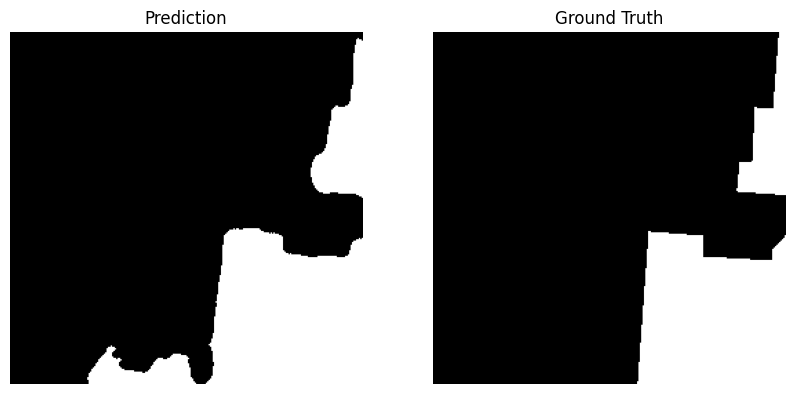

In [3]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load prediction
pred_path = r"C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\outputs\preds\thresholded\train_162_512_256.npy_th0.30_ma20.png"
pred = np.array(Image.open(pred_path))

# Load ground truth mask
mask_path = r"C:\Users\Rahul\CollegeProject\UrbanEyeML\ml\data\LEVIR_CD\chips_256\val\label\train_162_512_256.npy"
mask = np.load(mask_path)

# Plot side-by-side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(pred, cmap='gray')
ax[0].set_title("Prediction")
ax[0].axis('off')

ax[1].imshow(mask, cmap='gray')
ax[1].set_title("Ground Truth")
ax[1].axis('off')

plt.show()

In [6]:
import argparse
from pathlib import Path
import numpy as np
from PIL import Image
import pandas as pd
import random

IMG_EXTS = [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]

def load_img(path: Path) -> np.ndarray:
    """Load an image and convert to RGB numpy array."""
    with Image.open(path) as im:
        if im.mode != "RGB":
            im = im.convert("RGB")
        return np.array(im, dtype=np.float32) / 255.0

def load_mask(path: Path) -> np.ndarray:
    """Load mask and convert to binary {0,1}."""
    with Image.open(path) as im:
        if im.mode != "L":
            im = im.convert("L")
        mask = np.array(im, dtype=np.uint8)
        # Convert any non-zero pixel to 1 (change)
        return (mask > 0).astype(np.uint8)

def save_npy(arr: np.ndarray, filepath: Path):
    """Save numpy array to .npy file, creating parent dirs if necessary."""
    filepath.parent.mkdir(parents=True, exist_ok=True)
    np.save(str(filepath), arr)

def tile_and_save_pair(a_img: np.ndarray, b_img: np.ndarray, mask: np.ndarray, prefix: str,
                       chip_size: int, stride: int, out_dir: Path, split: str):
    """
    Tiles large images and mask into chips, saves as .npy files,
    and returns list of dict rows with file paths and split info.
    """
    height, width, _ = a_img.shape
    rows = []
    chips_saved = 0
    chips_skipped = 0
    
    for y in range(0, height - chip_size + 1, stride):
        for x in range(0, width - chip_size + 1, stride):
            a_chip = a_img[y:y+chip_size, x:x+chip_size, :]
            b_chip = b_img[y:y+chip_size, x:x+chip_size, :]
            mask_chip = mask[y:y+chip_size, x:x+chip_size]

            # Filter chips with too few change pixels
            n_change = np.sum(mask_chip == 1)
            if n_change < 5:
                chips_skipped += 1
                continue

            # Filter chips with too much change (likely mislabeled)
            if n_change > chip_size * chip_size * 0.9:
                chips_skipped += 1
                continue

            base_filename = f"{prefix}_{y}_{x}.npy"
            a_fp = out_dir / split / "A" / base_filename
            b_fp = out_dir / split / "B" / base_filename
            label_fp = out_dir / split / "label" / base_filename

            # Save in CHW format: (C, H, W)
            save_npy(np.transpose(a_chip, (2, 0, 1)), a_fp)
            save_npy(np.transpose(b_chip, (2, 0, 1)), b_fp)
            save_npy(mask_chip, label_fp)

            # Use relative paths from out_dir (simpler approach)
            a_rel = Path(split) / "A" / base_filename
            b_rel = Path(split) / "B" / base_filename
            label_rel = Path(split) / "label" / base_filename

            rows.append({
                "t0_npy": str(a_rel),
                "t1_npy": str(b_rel),
                "mask_npy": str(label_rel),
                "split": split
            })
            chips_saved += 1
    
    print(f"   💾 Saved: {chips_saved} chips, ⏭️ Skipped: {chips_skipped} chips")
    return rows

def main():
    parser = argparse.ArgumentParser(description="Tile paired images and masks into chips for change detection.")
    parser.add_argument("--a_dir", type=Path, required=True, help="Path to before images directory (T0)")
    parser.add_argument("--b_dir", type=Path, required=True, help="Path to after images directory (T1)")
    parser.add_argument("--label_dir", type=Path, required=True, help="Path to mask images directory (0/255)")
    parser.add_argument("--out_dir", type=Path, required=True, help="Output directory for chips and index.parquet")
    parser.add_argument("--chip_size", type=int, default=256, help="Chip (tile) size")
    parser.add_argument("--stride", type=int, default=256, help="Stride for tiling (non-overlapping)")
    parser.add_argument("--val_frac", type=float, default=0.15, help="Validation fraction")
    parser.add_argument("--test_frac", type=float, default=0.15, help="Test fraction")
    parser.add_argument("--seed", type=int, default=42, help="Random seed for splitting")
    args = parser.parse_args()

    # Validate input directories
    if not args.a_dir.exists() or not args.b_dir.exists() or not args.label_dir.exists():
        raise FileNotFoundError(f"Input directories missing:\n"
                              f"A: {args.a_dir} exists={args.a_dir.exists()}\n"
                              f"B: {args.b_dir} exists={args.b_dir.exists()}\n"
                              f"Label: {args.label_dir} exists={args.label_dir.exists()}")

    # Get all image files
    a_files = sorted([p for p in args.a_dir.iterdir() if p.suffix.lower() in IMG_EXTS])
    b_files = sorted([p for p in args.b_dir.iterdir() if p.suffix.lower() in IMG_EXTS])
    label_files = sorted([p for p in args.label_dir.iterdir() if p.suffix.lower() in IMG_EXTS])

    # Debug file counts
    print(f"📁 A files: {len(a_files)}")
    print(f"📁 B files: {len(b_files)}")
    print(f"📁 Label files: {len(label_files)}")

    assert len(a_files) == len(b_files) == len(label_files), \
        f"Mismatch in number of files: A={len(a_files)}, B={len(b_files)}, Label={len(label_files)}"

    print(f"✅ Found {len(a_files)} paired image-mask sets.")

    # Pair files and shuffle for split
    paired_files = list(zip(a_files, b_files, label_files))
    random.seed(args.seed)
    random.shuffle(paired_files)

    n = len(paired_files)
    n_val = int(n * args.val_frac)
    n_test = int(n * args.test_frac)
    n_train = n - n_val - n_test

    splits = ["train"] * n_train + ["val"] * n_val + ["test"] * n_test

    print(f"📊 Split: train={n_train}, val={n_val}, test={n_test}")

    all_rows = []
    total_chips = 0

    for i, ((a_fp, b_fp, label_fp), split) in enumerate(zip(paired_files, splits)):
        prefix = a_fp.stem
        print(f"[{i+1}/{n}] Processing {prefix} ({split})...")

        try:
            a_img = load_img(a_fp)
            b_img = load_img(b_fp)
            mask = load_mask(label_fp)  # ✅ Now returns {0,1}

            # Validate shapes
            if a_img.shape[:2] != b_img.shape[:2] or a_img.shape[:2] != mask.shape:
                print(f"⚠️ Shape mismatch in {prefix}: A={a_img.shape}, B={b_img.shape}, Mask={mask.shape}")
                continue

            # Check if mask has any change pixels
            n_change_total = np.sum(mask == 1)
            if n_change_total == 0:
                print(f"⚠️ No change pixels in {prefix}, skipping...")
                continue

            rows = tile_and_save_pair(a_img, b_img, mask, prefix, args.chip_size, args.stride, 
                                     args.out_dir, split)
            all_rows.extend(rows)
            total_chips += len(rows)

        except Exception as e:
            print(f"❌ Error processing {prefix}: {e}")
            continue

    # Save index
    if all_rows:
        df = pd.DataFrame(all_rows)
        index_fp = args.out_dir / "index.parquet"
        df.to_parquet(index_fp, index=False)

        print(f"\n🎉 COMPLETE!")
        print(f"✅ Total valid chips generated: {total_chips:,}")
        print(f"📊 Saved metadata to: {index_fp}")
        print(f"📁 Output directory: {args.out_dir}")

        # Print split summary
        split_counts = df['split'].value_counts()
        print("\n--- SPLIT SUMMARY ---")
        for split, count in split_counts.items():
            pct = count / len(df) * 100
            print(f"  {split:>5}: {count:>6} chips ({pct:>5.1f}%)")
    else:
        print("❌ No valid chips generated! Check your input data.")

if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] --a_dir A_DIR --b_dir B_DIR --label_dir
                             LABEL_DIR --out_dir OUT_DIR
                             [--chip_size CHIP_SIZE] [--stride STRIDE]
                             [--val_frac VAL_FRAC] [--test_frac TEST_FRAC]
                             [--seed SEED]
ipykernel_launcher.py: error: the following arguments are required: --a_dir, --b_dir, --label_dir, --out_dir


SystemExit: 2